In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\ott_review_Dataset\all_ott_shows.csv")

df = df.rename(columns={
"title":"title",
"type":"content_type",
"release_year":"release_year",
"rating":"age_rating",
"genre":"genre",
"platform":"platform",
"duration":"duration",
"description":"description",
"cast":"cast"
})

df['content_id'] = range(len(df))

df = df[
[
'content_id',
'title',
'content_type',
'release_year',
'age_rating',
'genre',
'platform',
'duration',
'description',
'cast'
]
]

df.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\ott_content_dataset.csv",index=False)

print("OTT dataset shape:",df.shape)

OTT dataset shape: (22998, 10)


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Consistent plot style across all notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [19]:
print(f"Shape: {df.shape}")
print(f"Platforms: {df['platform'].unique()}")
print(f"Year range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")

Shape: (22998, 10)
Platforms: ['Netflix' 'Amazon' 'Hulu' 'Disney']
Year range: 1920 – 2021
Missing values:
content_id         0
title              0
content_type       0
release_year       0
age_rating       864
genre              0
platform           0
duration         482
description        4
cast            5321
dtype: int64


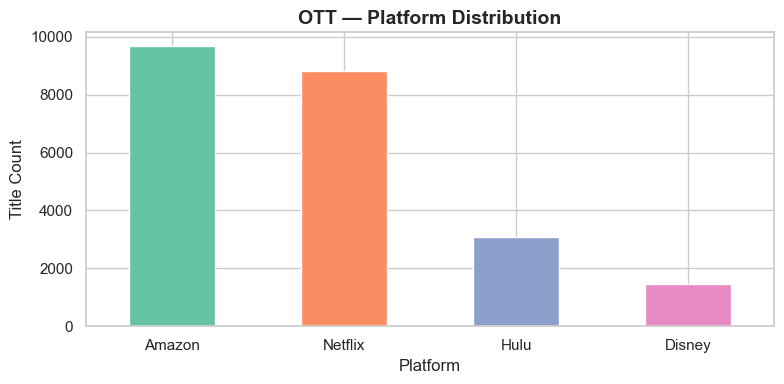

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
df["platform"].value_counts().head(10).plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2"), edgecolor="white"
)
ax.set_title("OTT — Platform Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Platform")
ax.set_ylabel("Title Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\ott\platform_distribution.png", dpi=150)
plt.tight_layout()
plt.show()

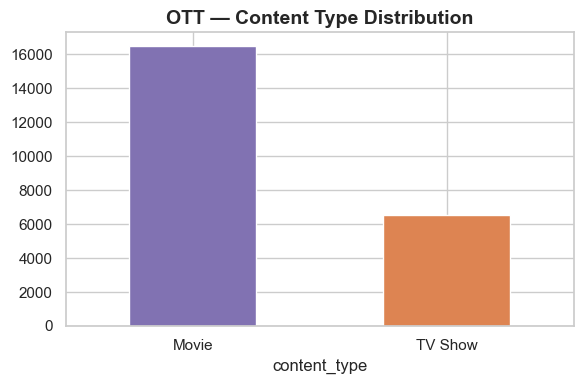

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
df["content_type"].value_counts().plot(
    kind="bar", ax=ax, color=["#8172B2","#DD8452"], edgecolor="white"
)
ax.set_title("OTT — Content Type Distribution", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\ott\content_type.png", dpi=150)
plt.show()

In [22]:
top_genres = df["genre"].value_counts().head(12)
print(top_genres)

genre
Drama                           1061
Comedy                           608
Documentaries                    573
Comedy, Drama                    421
Drama, Suspense                  399
Documentary                      375
Animation, Kids                  373
Kids                             367
Dramas, International Movies     362
Stand-Up Comedy                  334
Horror                           305
Action, Drama                    303
Name: count, dtype: int64


genre
Drama                           1061
Comedy                           608
Documentaries                    573
Comedy, Drama                    421
Drama, Suspense                  399
Documentary                      375
Animation, Kids                  373
Kids                             367
Dramas, International Movies     362
Stand-Up Comedy                  334
Horror                           305
Action, Drama                    303
Name: count, dtype: int64


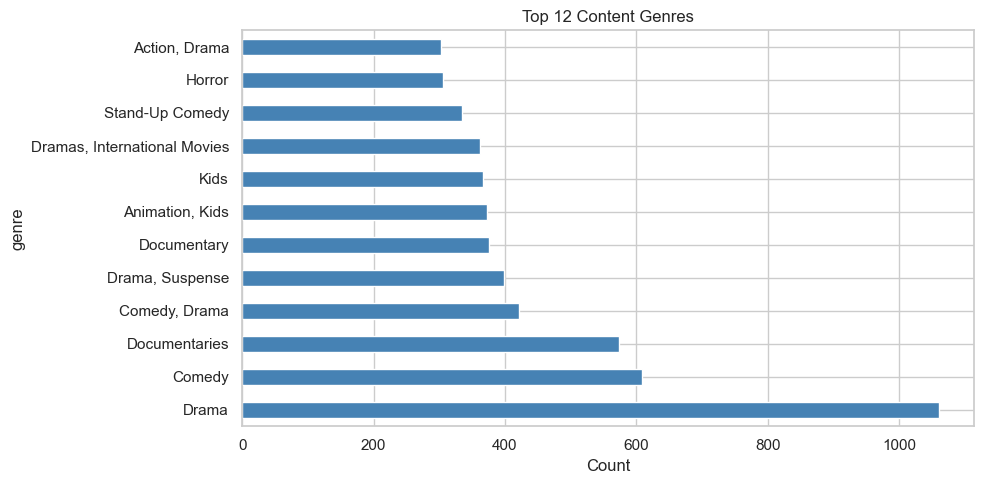

In [23]:
top_genres = df["genre"].value_counts().head(12)
print(top_genres)

ax = top_genres.plot(kind="barh", color="steelblue", edgecolor="white")
ax.set_title("Top 12 Content Genres")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

In [24]:
# 1. Split the strings by comma and turn them into lists
df['genre'] = df['genre'].str.split(', ')

# 2. 'Explode' the lists into individual rows
df_exploded = df.explode('genre')

# 3. Standardize naming (e.g., changing 'Documentaries' to 'Documentary')
df_exploded['genre'] = df_exploded['genre'].replace({'Documentaries': 'Documentary', 'Dramas': 'Drama'})

# 4. Now run value_counts again
clean_counts = df_exploded['genre'].value_counts()
print(clean_counts)

genre
Drama                   7155
Comedy                  3292
International Movies    2752
Documentary             2560
Action                  2212
                        ... 
Romantic Comedy            2
Disaster                   2
Police/Cop                 1
Talk Show                  1
Travel                     1
Name: count, Length: 118, dtype: int64


In [25]:
top_genres = df_exploded["genre"].value_counts().head(12)
print(top_genres)

genre
Drama                     7155
Comedy                    3292
International Movies      2752
Documentary               2560
Action                    2212
Comedies                  1674
Suspense                  1501
Kids                      1388
International TV Shows    1351
Horror                    1179
Animation                 1089
Special Interest           980
Name: count, dtype: int64


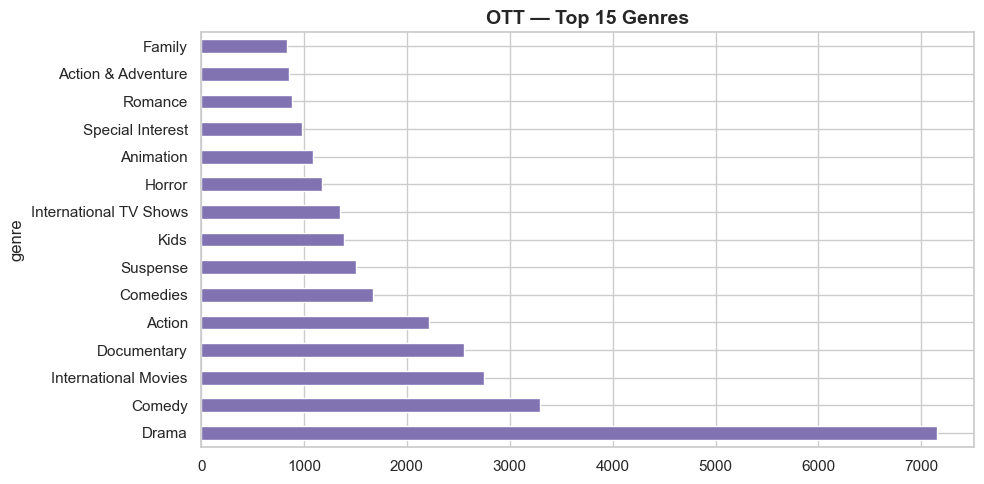

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
df_exploded["genre"].value_counts().head(15).plot(
    kind="barh", ax=ax, color="#8172B2"
)
ax.set_title("OTT — Top 15 Genres", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\ott\top_genres.png", dpi=150)
plt.show()

In [8]:
df_exploded.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\ott_content_dataset.csv",index=False)

In [27]:
df = df_exploded

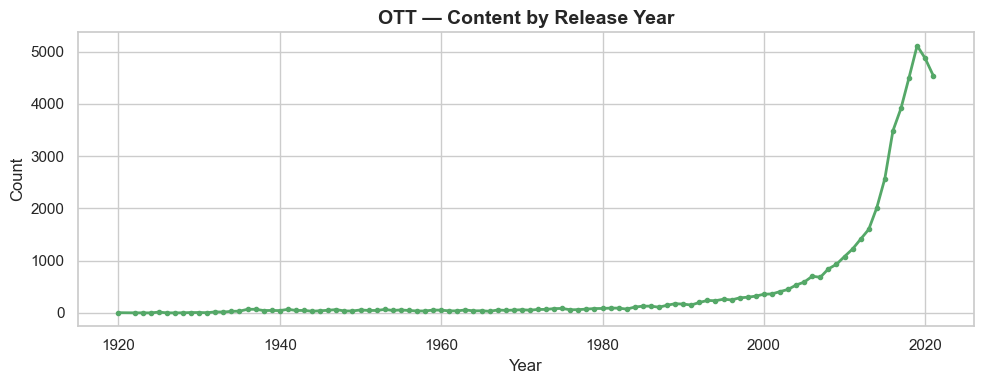

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
df["release_year"].value_counts().sort_index().plot(
    kind="line", ax=ax, color="#55A868", linewidth=2, marker="o", markersize=3
)
ax.set_title("OTT — Content by Release Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\ott\release_year_trend.png", dpi=150)
plt.show()

In [29]:
#to combine all the tweets
sentences = df_exploded["genre"].tolist()
len(sentences)

48303

In [30]:
sentences_to_string = " ".join(sentences)

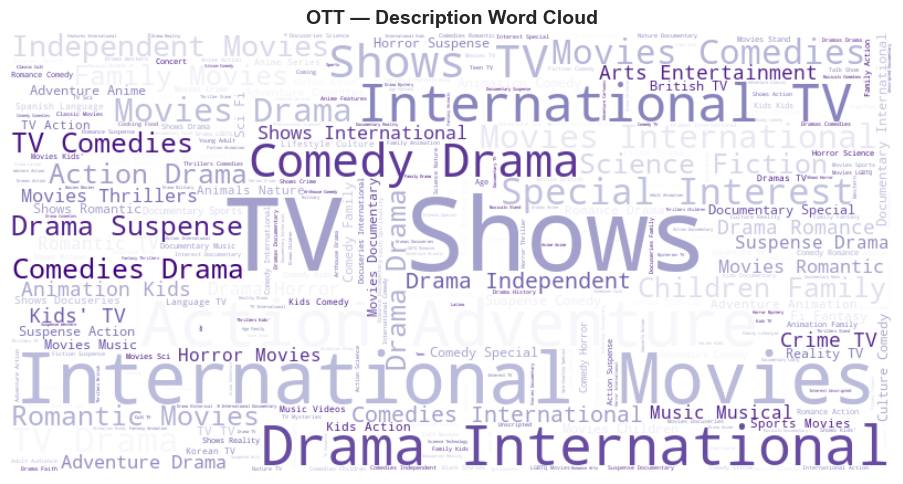


All OTT EDA images saved to reports/eda/ott/


In [36]:
from wordcloud import WordCloud
# plt.figure(figsize=(20,20))
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="Purples", max_words=2000).generate(sentences_to_string)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("OTT — Description Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\ott\wordcloud.png", dpi=150)
plt.show()

print("\nAll OTT EDA images saved to reports/eda/ott/")